In [4]:
import pandas as pd
import optuna
import shap
from pathlib import Path

from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor

1. Load Boston dataset

In [5]:
url = "https://raw.githubusercontent.com/selva86/datasets/refs/heads/master/BostonHousing.csv"
df = pd.read_csv(url)

X = df.drop(columns=['medv'])
y = df[['medv']]

2. Split data into test/train

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

3. Inicialize DecissionTreeRegressor

In [7]:
model = DecisionTreeRegressor()

4. Fit regressor

In [8]:
model.fit(X_train, y_train)

DecisionTreeRegressor()

5. Predict results

In [9]:
predictions = model.predict(X_test)

6. Score MSE/RMSE/MAPE

In [10]:
mse = mean_squared_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)
{'mse': mse, 'rmse': rmse, 'mape': mape}


{'mse': 13.853627450980394,
 'rmse': 3.722046137674867,
 'mape': 0.14791473847829847}

7. Optimize hyper parameters using optima

In [11]:
def objective(trial):
    max_depth = int(trial.suggest_float('max_depth', 1, 32, log=True))
    min_samples_split = int(trial.suggest_float('min_samples_split', 2, 32, log=True))
    
    clf = DecisionTreeRegressor(max_depth=max_depth, min_samples_split=min_samples_split)
    
    return cross_val_score(clf, X, y, n_jobs=1, cv=3).mean()
    
    
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)
trial = study.best_trial
trial

[I 2024-11-20 17:30:16,216] A new study created in memory with name: no-name-8595b924-682e-4e41-9ad1-a01abf8f0310
[I 2024-11-20 17:30:16,235] Trial 0 finished with value: 0.258520181144166 and parameters: {'max_depth': 19.178708628194922, 'min_samples_split': 2.8888162759016276}. Best is trial 0 with value: 0.258520181144166.
[I 2024-11-20 17:30:16,245] Trial 1 finished with value: 0.49835337039917355 and parameters: {'max_depth': 4.080215751479603, 'min_samples_split': 29.901249625060302}. Best is trial 1 with value: 0.49835337039917355.
[I 2024-11-20 17:30:16,258] Trial 2 finished with value: 0.30772844694030504 and parameters: {'max_depth': 13.705297930985967, 'min_samples_split': 2.2463308782971954}. Best is trial 1 with value: 0.49835337039917355.
[I 2024-11-20 17:30:16,264] Trial 3 finished with value: -0.052570804522194536 and parameters: {'max_depth': 1.1751248316930158, 'min_samples_split': 26.427465973279446}. Best is trial 1 with value: 0.49835337039917355.
[I 2024-11-20 17:

FrozenTrial(number=32, state=TrialState.COMPLETE, values=[0.5227739981763074], datetime_start=datetime.datetime(2024, 11, 20, 17, 30, 16, 576581), datetime_complete=datetime.datetime(2024, 11, 20, 17, 30, 16, 586963), params={'max_depth': 5.2585584343348035, 'min_samples_split': 26.413450261729086}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'max_depth': FloatDistribution(high=32.0, log=True, low=1.0, step=None), 'min_samples_split': FloatDistribution(high=32.0, log=True, low=2.0, step=None)}, trial_id=32, value=None)

In [13]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

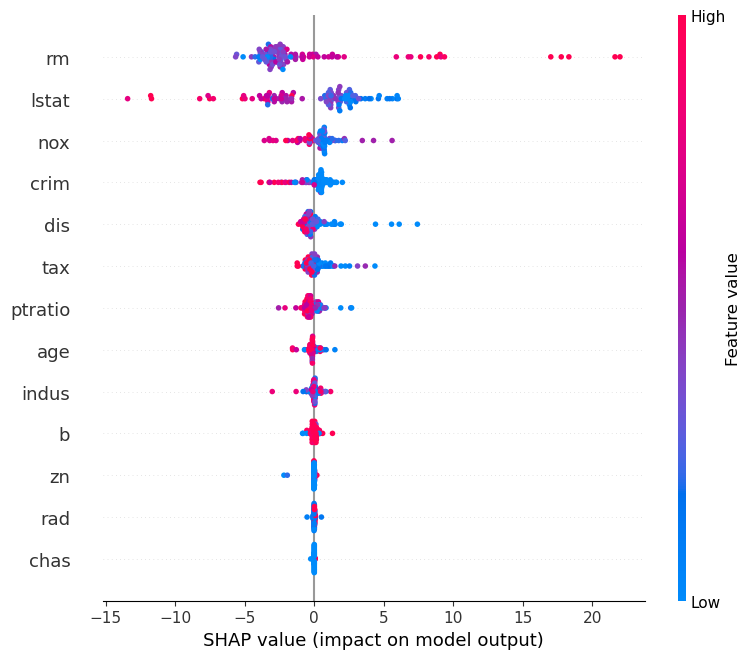

In [14]:
shap.summary_plot(shap_values, X_test)